In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('./btcusdt_3m.csv', parse_dates=['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

# Parameters
ema_period = 20  # Period for EMA
threshold_pct = 0.02  # Threshold for mean reversion (7% above/below EMA)
initial_capital = 100000  # Initial capital in USDT

# Calculate EMA (Exponential Moving Average)
df['EMA'] = df['close'].ewm(span=ema_period, adjust=False).mean()

# Step 1: Generate Positions
# Initialize positions: 1 for long, -1 for short, 0 for neutral
df['Position'] = 0

for i in range(1, len(df)):
    current_price = df['close'].iloc[i]
    ema = df['EMA'].iloc[i]
    lower_threshold = ema * (1 - threshold_pct)
    upper_threshold = ema * (1 + threshold_pct)
    
    # Long condition: Price < lower_threshold
    if current_price < lower_threshold:
        df.at[i, 'Position'] = 1  # Go long
    
    # Short condition: Price > upper_threshold
    elif current_price > upper_threshold:
        df.at[i, 'Position'] = -1  # Go short
    
    # Else: Neutral (Position remains 0)



/tmp/ipykernel_230872/845169220.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '574.126798000003' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i,'trades']=profit_loss


Gross Profit: 1722273.42
Net Profit: 486226.06
Gross Loss: -1236047.36
Total Closed Trades: 39978.00
Number of Winning Trades: 26990.00
Number of Losing Trades: 12988.00
Average Winning Trade (USDT): 63.81
Average Losing Trade (USDT): -95.17
Largest Winning Trade (USDT): 1096.90
Largest Losing Trade (USDT): -3137.40
Max Drawdown: -165542.70
Sharpe Ratio: 0.00
Sortino Ratio: 0.00


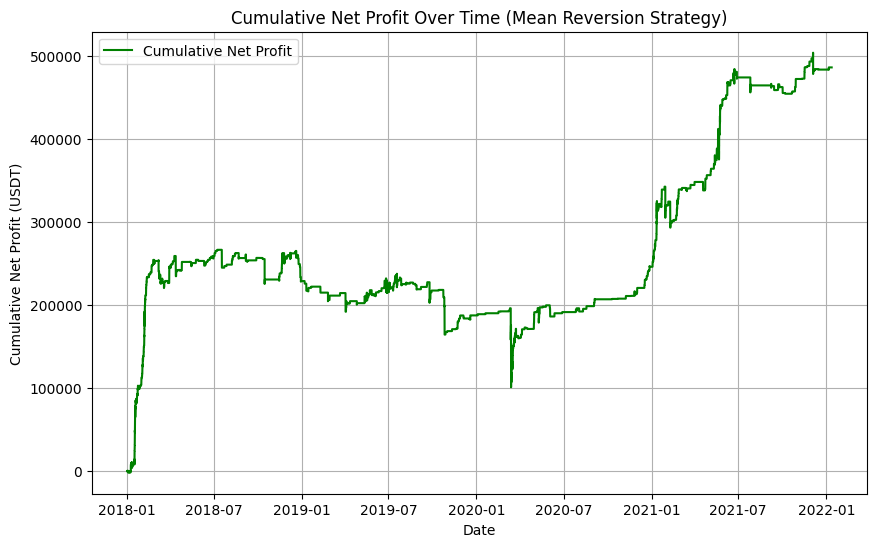

In [29]:
# Initialize variables for tracking trades and capital invested
df['trades']=0
df['num_trades']=0
trades = []
current_capital = initial_capital  # Track the current capital
prev_position = 0  # Track the current position (1 for long, -1 for short, 0 for neutral)
entry_price = None  # Track entry price for calculating profit/loss
brokerage = 0.1/1000 #0.1%

# Iterate over the DataFrame to capture trade profits/losses
for i in range(1, len(df)):
    # Check if position changes
    if df['Position'].iloc[i] != prev_position:
        # Exiting long position
        if prev_position == 1:
            exit_price=(df['close'].iloc[i])*(1-brokerage)
            profit_loss = (exit_price - entry_price) * (current_capital // entry_price)
            trades.append(profit_loss)  # Append the realized profit/loss
            df.loc[i,'trades']=profit_loss
            df.loc[i,'num_trades']=current_capital // entry_price
            current_capital += profit_loss  # Update current capital
            prev_position = df['Position'].iloc[i]  # Update previoous position
            entry_price = None  # Reset entry price
        
        # Exiting short position
        elif prev_position == -1:
            exit_price=(df['close'].iloc[i])*(1+brokerage)
            profit_loss = (entry_price - exit_price) * (current_capital // entry_price)
            trades.append(profit_loss)  # Append the realized profit/loss
            df.loc[i,'trades']=profit_loss
            df.loc[i,'num_trades']=current_capital // entry_price
            current_capital += profit_loss  # Update current capital
            prev_position = df['Position'].iloc[i]  # Update previoous position
            entry_price = None  # Reset entry price
        
        # Entering long position
        if df['Position'].iloc[i] == 1:
            entry_price = (df['close'].iloc[i])*(1+brokerage)  # Capture entry price for long
            prev_position = 1  # Update to long position
        
        # Entering short position
        elif df['Position'].iloc[i] == -1:
            entry_price = (df['close'].iloc[i])*(1-brokerage)  # Capture entry price for short
            prev_position = -1  # Update to short position

winning_trades = df[df['trades'] > 0]
losing_trades = df[df['trades'] < 0]
# Sum the 'num_trades' column for all winning trades
num_winning_trades = winning_trades['num_trades'].sum()
num_losing_trades = losing_trades['num_trades'].sum()
# Count total trades and calculate other metrics
gross_profit = winning_trades['trades'].sum()
gross_loss = losing_trades['trades'].sum()

average_winning_trade = (winning_trades['trades'].sum())/(winning_trades['num_trades'].sum()) if num_winning_trades > 0 else 0
average_losing_trade = (losing_trades['trades'].sum())/(losing_trades['num_trades'].sum()) if num_losing_trades > 0 else 0
largest_winning_trade = (winning_trades['trades']/winning_trades['num_trades']).max() if num_winning_trades > 0 else 0
largest_losing_trade = (losing_trades['trades']/losing_trades['num_trades']).min() if num_losing_trades > 0 else 0
net_profit=gross_profit+gross_loss

# Calculate cumulative net profit over time for plotting
df['Cumulative_Profit_Loss'] = df['trades'].cumsum().fillna(0)  # Fill missing values with 0
df['Returns'] = (df['Cumulative_Profit_Loss']+100000).pct_change().fillna(0)

# Risk-free rate 
risk_free_rate = 0  # 0% annually
days_in_year = 365  # Approximate number of trading days in a year
daily_risk_free_rate = (1 + risk_free_rate) ** (1 / days_in_year) - 1
# Calculate average daily return and standard deviation of daily returns
average_return = df['Returns'].mean()
std_dev_return = df['Returns'].std()
# Calculate the Sharpe Ratio
sharpe_ratio = (average_return - daily_risk_free_rate) / std_dev_return

# Filter the negative returns (downside returns)
negative_returns = df[df['Returns'] < daily_risk_free_rate]['Returns']
# Calculate downside deviation (standard deviation of negative returns)
downside_deviation = negative_returns.std()
# Calculate the Sortino Ratio
sortino_ratio = (average_return - daily_risk_free_rate) / downside_deviation

df['Portfolio']=df['Cumulative_Profit_Loss']+100000
#Calculate the running maximum of the portfolio
df['Peak']=0
df['Peak'] = df['Portfolio'].cummax()
#Calculate the drawdown
df['Drawdown'] = (df['Peak'] - df['Portfolio']) / df['Peak']
#Convert drawdown to percentage
df['Drawdown_pct'] = df['Drawdown'] * 100
# Find the maximum drawdown
max_drawdown = df['Drawdown_pct'].max()
drawdown=-(df['Peak'] - df['Portfolio']).max()
# Output all metrics
metrics = {
    "Gross Profit": gross_profit,
    "Net Profit": net_profit,
    "Gross Loss": gross_loss,
    "Total Closed Trades": num_winning_trades+num_losing_trades,
    "Number of Winning Trades": num_winning_trades,
    "Number of Losing Trades": num_losing_trades,
    "Average Winning Trade (USDT)": average_winning_trade,
    "Average Losing Trade (USDT)": average_losing_trade,
    "Largest Winning Trade (USDT)": largest_winning_trade,
    "Largest Losing Trade (USDT)": largest_losing_trade,
    "Max Drawdown": drawdown,
    "Sharpe Ratio": sharpe_ratio,
    "Sortino Ratio": sortino_ratio
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.2f}")

# Plot net profit over time
plt.figure(figsize=(10, 6))
plt.plot(df['datetime'], df['Cumulative_Profit_Loss'], label='Cumulative Net Profit', color='g')
plt.title('Cumulative Net Profit Over Time (Mean Reversion Strategy)')
plt.xlabel('Date')
plt.ylabel('Cumulative Net Profit (USDT)')
plt.grid(True)
plt.legend()
plt.show()

In [26]:
df.tail(50)

,datetime,open,high,low,close,volume,EMA,Position,trades,num_trades,Cumulative_Profit_Loss,Returns,Portfolio,Peak,Drawdown,Drawdown_pct
703847,2022-01-12 03:03:00,42664.70,42709.00,42654.05,42708.99,40.88074,42749.559796,0,0.0,0,486226.056314,0.0,586226.056314,603914.829165,0.02929,2.929018
703848,2022-01-12 03:06:00,42708.99,42770.87,42705.09,42744.22,69.10089,42749.051244,0,0.0,0,486226.056314,0.0,586226.056314,603914.829165,0.02929,2.929018
703849,2022-01-12 03:09:00,42744.21,42748.48,42723.37,42735.65,15.93910,42747.774935,0,0.0,0,486226.056314,0.0,586226.056314,603914.829165,0.02929,2.929018
703850,2022-01-12 03:12:00,42735.66,42739.99,42677.96,42718.97,38.31288,42745.031608,0,0.0,0,486226.056314,0.0,586226.056314,603914.829165,0.02929,2.929018
703851,2022-01-12 03:15:00,42718.98,42727.93,42675.79,42692.80,23.45505,42740.057169,0,0.0,0,486226.056314,0.0,586226.056314,603914.829165,0.02929,2.929018
703852,2022-01-12 03:18:00,42692.80,42759.84,42680.00,42747.48,42.64906,42740.764106,0,0.0,0,486226.056314,0.0,586226.056314,603914.829165,0.02929,2.929018
703853,2022-01-12 03:21:00,42747.48,42759.83,42708.66,42720.99,23.44715,42738.880857,0,0.0,0,486226.056314,0.0,586226.056314,603914.829165,0.02929,2.929018
703854,2022-01-12 03:24:00,42720.11,42720.99,42655.75,42679.33,43.89433,42733.209347,0,0.0,0,486226.056314,0.0,586226.056314,603914.829165,0.02929,2.929018
703855,2022-01-12 03:27:00,42679.33,42709.76,42643.74,42659.20,27.33349,42726.160838,0,0.0,0,486226.056314,0.0,586226.056314,603914.829165,0.02929,2.929018
703856,2022-01-12 03:30:00,42664.71,42712.00,42633.80,42670.54,38.95066,42720.863615,0,0.0,0,486226.056314,0.0,586226.056314,603914.829165,0.02929,2.929018
